<a href="https://colab.research.google.com/github/JoshOmondi/Loan-Predictions/blob/master/loan-pediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Loan Prediction with Various Models

####importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as mso
import seaborn as sns
import warnings
import os
import scipy

from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

####Uploading the file

In [3]:
from google.colab import files
files.upload()

Saving kaggle (9).json to kaggle (9) (3).json


{'kaggle (9) (3).json': b'{"username":"joshua10542","key":"c5f89c1c309e9609f2d67f241659b6f9"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp "kaggle (9).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets list -s loan-prediction

ref                                                    title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
kmldas/loan-default-prediction                         Loan Default Prediction                            111675  2021-04-06 15:03:41.200000          13343        117                1  
architsharma01/loan-approval-prediction-dataset        Loan-Approval-Prediction-Dataset                    82535  2023-07-16 16:31:20.923000          50235        263                1  
bhavikjikadara/loan-status-prediction                  Loan Status Prediction                               5336  2024-02-02 13:27:20.870000          15505        111                1  
nikhil1e9/loan-default                                 Loan Default Pr

In [6]:
!kaggle datasets download -d altruistdelhite04/loan-prediction-problem-dataset
!unzip -q loan-prediction-problem-dataset.zip -d loan-prediction-problem-dataset

Dataset URL: https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset
License(s): unknown
loan-prediction-problem-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace loan-prediction-problem-dataset/test_Y3wMUE5_7gLdaTN.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: r
new name: train_u6lujuX_CVtuZ9i.csv
replace loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


####Dataset information

In [7]:
df = pd.read_csv("/content/loan-prediction-problem-dataset/train_u6lujuX_CVtuZ9i.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [9]:
df.isnull().sum()


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [10]:
# Drop rows with very few missing
df.dropna(subset=['Married'], inplace=True)

# Drop the 3 rows where Married is null
df.dropna(subset=['Married'], inplace=True)

# Numerical → median
for col in ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical → mode
for col in ['Gender', 'Dependents', 'Self_Employed']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify
df.isnull().sum()

/tmp/ipykernel_15401/1446894892.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_15401/1446894892.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


###Univariate Analysis

In [11]:
!pip uninstall pandas-profiling visions -y --quiet

In [12]:
!pip install -U ydata-profiling --quiet

In [13]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, minimal=True)  # minimal=True is lighter on memory, good for Colab
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 22.29it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [16]:
# Drop the ID column — it's just a unique identifier, not informative
df_corr = df.drop(columns=['Loan_ID'])

# Encode categorical columns as numeric codes
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

# Now correlation works on everything meaningful
correlation_matrix = df_corr.corr()
correlation_matrix

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Gender,1.000000,0.367926,0.172422,0.044560,-0.001284,0.061997,0.082028,0.106319,-0.082177,0.010004,-0.026958,0.019381
Married,0.367926,1.000000,0.337748,0.014223,0.005904,0.051332,0.077770,0.146611,-0.102624,0.009481,0.002918,0.089280
Dependents,0.172422,0.337748,1.000000,0.053947,0.055471,0.118901,0.028788,0.163450,-0.103619,-0.038736,0.001121,0.012593
Education,0.044560,0.014223,0.053947,1.000000,-0.011414,-0.140590,-0.063585,-0.168847,-0.073701,-0.072670,-0.064391,-0.084286
Self_Employed,-0.001284,0.005904,0.055471,-0.011414,1.000000,0.127550,-0.017019,0.115209,-0.033421,-0.000757,-0.030184,-0.002404
ApplicantIncome,0.061997,0.051332,0.118901,-0.140590,0.127550,1.000000,-0.116266,0.565869,-0.044361,-0.018900,-0.008948,-0.005154
CoapplicantIncome,0.082028,0.077770,0.028788,-0.063585,-0.017019,-0.116266,1.000000,0.189393,-0.059135,0.012093,0.011051,-0.057733
LoanAmount,0.106319,0.146611,0.163450,-0.168847,0.115209,0.565869,0.189393,1.000000,0.036041,-0.000652,-0.047087,-0.033275
Loan_Amount_Term,-0.082177,-0.102624,-0.103619,-0.073701,-0.033421,-0.044361,-0.059135,0.036041,1.000000,-0.005291,-0.077171,-0.023619
Credit_History,0.010004,0.009481,-0.038736,-0.072670,-0.000757,-0.018900,0.012093,-0.000652,-0.005291,1.000000,0.001205,0.540021


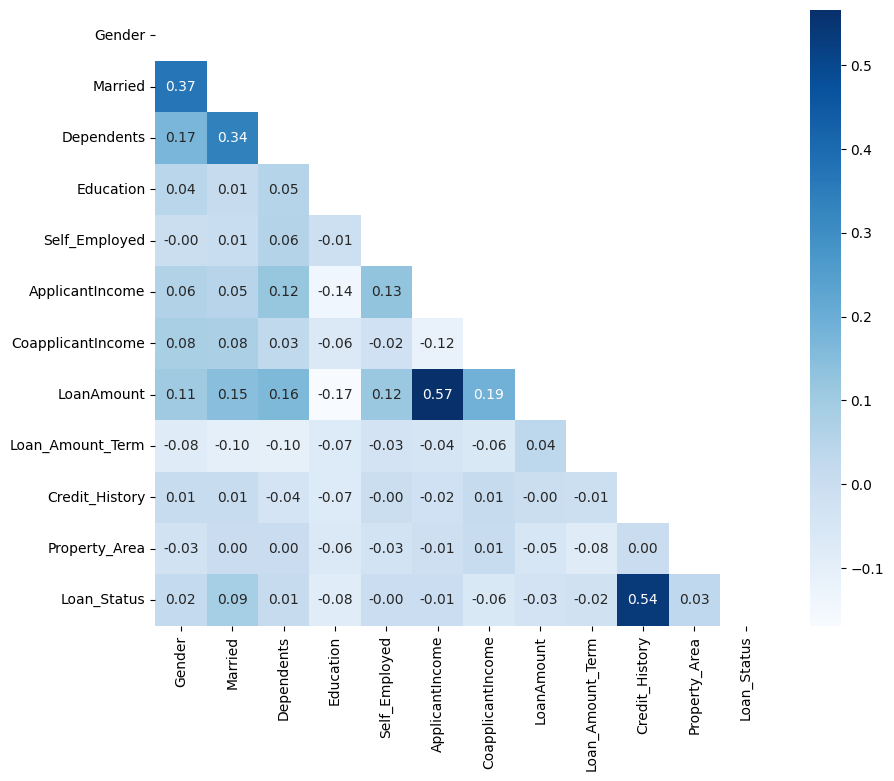

In [17]:
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  #hide upper triangle, like your first plotsns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='Blues', square=True)
plt.show()